# Lab-to-Field Crop Disease Domain Generalisation Benchmark
**Run cells top-to-bottom.** Cell 6 builds both `final_dataset` (PlantVillage) and `plantdoc_aligned` (PlantDoc) — re-run it whenever the Colab session resets.

In [1]:
# ── CELL 0: Mount Drive + Python path ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/idea4drive')
print('Drive mounted. sys.path updated.')

Mounted at /content/drive
Drive mounted. sys.path updated.


In [2]:
!ls

drive  sample_data


In [2]:
# ── CELL 1: Reload all modules (run after any .py edit) ─────────────────
import importlib
import data_pipeline, model, train, evaluate, domain_gap

importlib.reload(data_pipeline)
importlib.reload(model)
importlib.reload(train)
importlib.reload(evaluate)
importlib.reload(domain_gap)
print('All modules reloaded.')

All modules reloaded.


In [4]:
# ── CELL 2: Kaggle setup from Drive ─────────────────────────────────────
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/idea4drive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle setup done.')

Kaggle setup done.


In [5]:
# ── CELL 3: Install dependencies ────────────────────────────────────────
!pip install kaggle scikit-learn matplotlib seaborn --quiet
print('Dependencies installed.')

Dependencies installed.


In [6]:
# ── CELL 4: Download PlantVillage (skip if already downloaded) ──────────
import os
if not os.path.exists('/content/plantvillage dataset/color'):
    print('Downloading PlantVillage...')
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset
    !unzip -q plantvillage-dataset.zip
    print('Download + unzip done.')
else:
    print('PlantVillage already present, skipping download.')

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:24<00:00, 88.9MB/s]

Download + unzip done.


In [7]:
# ── CELL 5: Verify PlantDoc is in Drive ─────────────────────────────────
import os
pd_train = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train'
pd_test  = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test'
pv_color = '/content/plantvillage dataset/color'

for p, label in [(pv_color, 'PlantVillage color'), (pd_train, 'PlantDoc train'), (pd_test, 'PlantDoc test')]:
    exists = os.path.isdir(p)
    count  = len(os.listdir(p)) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}]  {label}: {p}  ({count} entries)')

if not os.path.isdir(pv_color):
    raise RuntimeError('PlantVillage not found — run Cell 4 first.')
if not os.path.isdir(pd_train):
    raise RuntimeError('PlantDoc not found in Drive — upload PlantDoc-Dataset-master to idea4drive.')

  [OK]  PlantVillage color: /content/plantvillage dataset/color  (38 entries)
  [OK]  PlantDoc train: /content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train  (29 entries)
  [OK]  PlantDoc test: /content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test  (28 entries)


In [8]:
# ── CELL 6: Class alignment + build final_dataset (PV) + plantdoc_aligned (PD)
# This is the KEY FIX: builds BOTH datasets in one idempotent cell.
# Re-run safely after session restart — checks existence before copying.

import re, os, json, shutil, random
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
PV_PATH       = '/content/plantvillage dataset/color'
PD_TRAIN_PATH = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train'
PD_TEST_PATH  = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test'

# Output dirs (ephemeral /content/ — rebuilt each session)
FINAL_TRAIN   = '/content/final_dataset/train'
FINAL_VAL     = '/content/final_dataset/val'
PD_ALIGNED_VAL = '/content/plantdoc_aligned/val'

EXCLUDE = {'.ds_store', 'ds_store', 'thumbs.db', '.thumbs'}

def load_classes(path):
    return [
        c for c in os.listdir(path)
        if os.path.isdir(os.path.join(path, c))
        and c.lower().strip() not in EXCLUDE
        and not c.startswith('.')
    ]

def clean_name(name: str) -> str:
    name = name.lower()
    name = re.sub(r'\bleaf\b', '', name)
    name = re.sub(r'[^a-z0-9]', '_', name)
    name = re.sub(r'_+', '_', name)
    return name.strip('_')

# ── Canonical mapping ──────────────────────────────────────────────────────
mapping = {
    'tomato_early_blight': 'tomato_early_blight',
    'tomato___early_blight': 'tomato_early_blight',
    'tomato_late_blight': 'tomato_late_blight',
    'tomato___late_blight': 'tomato_late_blight',
    'tomato_bacterial_spot': 'tomato_bacterial_spot',
    'tomato___bacterial_spot': 'tomato_bacterial_spot',
    'tomato_septoria_spot': 'tomato_septoria_leaf_spot',
    'tomato_septoria_leaf_spot': 'tomato_septoria_leaf_spot',
    'tomato___septoria_leaf_spot': 'tomato_septoria_leaf_spot',
    'tomato___septoria_spot': 'tomato_septoria_leaf_spot',
    'tomato_mold': 'tomato_leaf_mold',
    'tomato_leaf_mold': 'tomato_leaf_mold',
    'tomato__leaf_mold': 'tomato_leaf_mold',
    'tomato___leaf_mold': 'tomato_leaf_mold',
    'tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato_tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato___tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato__tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato_yellow_leaf_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_tomato_yellow_leaf_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato___tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_yellow_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_spider_mites': 'tomato_spider_mites',
    'tomato_spider_mites_two_spotted': 'tomato_spider_mites',
    'tomato___spider_mites_two_spotted': 'tomato_spider_mites',
    'tomato_spider_mites_two_spotted_spider_mite': 'tomato_spider_mites',
    'tomato_two_spotted_spider_mites': 'tomato_spider_mites',
    'tomato_target_spot': 'tomato_target_spot',
    'tomato__target_spot': 'tomato_target_spot',
    'tomato___target_spot': 'tomato_target_spot',
    'tomato_healthy': 'tomato_healthy',
    'tomato___healthy': 'tomato_healthy',
    'potato_early_blight': 'potato_early_blight',
    'potato___early_blight': 'potato_early_blight',
    'potato_late_blight': 'potato_late_blight',
    'potato___late_blight': 'potato_late_blight',
    'potato_healthy': 'potato_healthy',
    'potato___healthy': 'potato_healthy',
    'corn_common_rust': 'corn_common_rust',
    'maize_common_rust': 'corn_common_rust',
    'corn___common_rust': 'corn_common_rust',
    'corn_maize_common_rust': 'corn_common_rust',
    'corn_rust': 'corn_common_rust',
    'corn_northern_blight': 'corn_northern_leaf_blight',
    'corn_northern_leaf_blight': 'corn_northern_leaf_blight',
    'maize_northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn___northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn_maize_northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn_maize_northern_blight': 'corn_northern_leaf_blight',
    'corn_blight': 'corn_northern_leaf_blight',
    'corn_gray_leaf_spot': 'corn_gray_leaf_spot',
    'maize_gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn___gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn___cercospora_spot_gray': 'corn_gray_leaf_spot',
    'corn_maize_cercospora_leaf_spot_gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn_maize_cercospora_spot_gray_spot': 'corn_gray_leaf_spot',
    'corn_gray_spot': 'corn_gray_leaf_spot',
    'corn_healthy': 'corn_healthy',
    'maize_healthy': 'corn_healthy',
    'corn___healthy': 'corn_healthy',
    'corn_maize_healthy': 'corn_healthy',
    'apple_scab': 'apple_scab',
    'apple_apple_scab': 'apple_scab',
    'apple___apple_scab': 'apple_scab',
    'apple_black_rot': 'apple_black_rot',
    'apple___black_rot': 'apple_black_rot',
    'apple_cedar_rust': 'apple_cedar_rust',
    'apple_cedar_apple_rust': 'apple_cedar_rust',
    'apple___cedar_apple_rust': 'apple_cedar_rust',
    'apple_rust': 'apple_cedar_rust',
    'apple_healthy': 'apple_healthy',
    'apple___healthy': 'apple_healthy',
    'grape_black_rot': 'grape_black_rot',
    'grape___black_rot': 'grape_black_rot',
    'grape_esca': 'grape_esca',
    'grape_esca_black_measles': 'grape_esca',
    'grape___esca_black_measles': 'grape_esca',
    'grape_isariopsis_blight': 'grape_leaf_blight',
    'grape_leaf_blight': 'grape_leaf_blight',
    'grape___isariopsis_blight': 'grape_leaf_blight',
    'grape_leaf_blight_isariopsis_leaf_spot': 'grape_leaf_blight',
    'grape_blight_isariopsis_spot': 'grape_leaf_blight',
    'grape___blight_isariopsis_spot': 'grape_leaf_blight',
    'grape_healthy': 'grape_healthy',
    'grape___healthy': 'grape_healthy',
    'pepper_bell_bacterial_spot': 'pepper_bacterial_spot',
    'pepper___bell___bacterial_spot': 'pepper_bacterial_spot',
    'pepper_bacterial_spot': 'pepper_bacterial_spot',
    'pepper_bell_healthy': 'pepper_healthy',
    'pepper___bell___healthy': 'pepper_healthy',
    'pepper_healthy': 'pepper_healthy',
    'bell_pepper_healthy': 'pepper_healthy',
    'squash_powdery_mildew': 'squash_powdery_mildew',
    'squash___powdery_mildew': 'squash_powdery_mildew',
    'strawberry_scorch': 'strawberry_leaf_scorch',
    'strawberry_leaf_scorch': 'strawberry_leaf_scorch',
    'strawberry___leaf_scorch': 'strawberry_leaf_scorch',
    'strawberry___scorch': 'strawberry_leaf_scorch',
    'strawberry_healthy': 'strawberry_healthy',
    'strawberry___healthy': 'strawberry_healthy',
    'peach_bacterial_spot': 'peach_bacterial_spot',
    'peach___bacterial_spot': 'peach_bacterial_spot',
    'peach_healthy': 'peach_healthy',
    'peach___healthy': 'peach_healthy',
    'cherry_powdery_mildew': 'cherry_powdery_mildew',
    'cherry___powdery_mildew': 'cherry_powdery_mildew',
    'cherry_including_sour_powdery_mildew': 'cherry_powdery_mildew',
    'cherry_healthy': 'cherry_healthy',
    'cherry___healthy': 'cherry_healthy',
    'cherry_including_sour_healthy': 'cherry_healthy',
    'blueberry_healthy': 'blueberry_healthy',
    'blueberry___healthy': 'blueberry_healthy',
    'raspberry_healthy': 'raspberry_healthy',
    'raspberry___healthy': 'raspberry_healthy',
    'soybean_healthy': 'soybean_healthy',
    'soybean___healthy': 'soybean_healthy',
    'orange_haunglongbing_citrus_greening': 'orange_huanglongbing',
    'orange___haunglongbing_citrus_greening': 'orange_huanglongbing',
}

# ── Compute common classes ─────────────────────────────────────────────────
pv_classes = load_classes(PV_PATH)
pd_classes = list(set(load_classes(PD_TRAIN_PATH)) | set(load_classes(PD_TEST_PATH)))

pv_clean = [clean_name(c) for c in pv_classes]
pd_clean = [clean_name(c) for c in pd_classes]

pv_mapped = [mapping.get(c, c) for c in pv_clean]
pd_mapped = [mapping.get(c, c) for c in pd_clean]

common_classes = set(pv_mapped) & set(pd_mapped)

class_to_idx = {cls: idx for idx, cls in enumerate(sorted(common_classes))}

print(f'Common classes found: {len(common_classes)}')
for c in sorted(common_classes):
    print(f'  [{class_to_idx[c]:2d}]  {c}')

# ── Helper: copy images from a raw source folder ───────────────────────────
def copy_images_from_folder(src_folder, dst_folder):
    """Copy all valid images from src_folder to dst_folder."""
    os.makedirs(dst_folder, exist_ok=True)
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}
    copied = 0
    for fname in os.listdir(src_folder):
        if fname.startswith('.'):
            continue
        if Path(fname).suffix.lower() not in valid_ext:
            continue
        src = os.path.join(src_folder, fname)
        dst = os.path.join(dst_folder, fname)
        if not os.path.exists(dst):  # skip if already copied (idempotent)
            shutil.copy2(src, dst)
        copied += 1
    return copied

# ── BUILD 1: final_dataset (PlantVillage → train 80% / val 20%) ────────────
print('\n' + '='*60)
print('BUILDING final_dataset (PlantVillage) ...')
print('='*60)

random.seed(42)
for cls in common_classes:
    os.makedirs(os.path.join(FINAL_TRAIN, cls), exist_ok=True)
    os.makedirs(os.path.join(FINAL_VAL,   cls), exist_ok=True)

pv_total = 0
for raw, cleaned in zip(pv_classes, pv_clean):
    canonical = mapping.get(cleaned, cleaned)
    if canonical not in common_classes:
        continue
    src_dir   = os.path.join(PV_PATH, raw)
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}
    images    = [
        f for f in os.listdir(src_dir)
        if not f.startswith('.') and Path(f).suffix.lower() in valid_ext
    ]
    for img in images:
        src = os.path.join(src_dir, img)
        if random.random() < 0.8:
            dst = os.path.join(FINAL_TRAIN, canonical, img)
        else:
            dst = os.path.join(FINAL_VAL, canonical, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        pv_total += 1

train_count = sum(len(os.listdir(os.path.join(FINAL_TRAIN, c))) for c in common_classes if os.path.isdir(os.path.join(FINAL_TRAIN, c)))
val_count   = sum(len(os.listdir(os.path.join(FINAL_VAL,   c))) for c in common_classes if os.path.isdir(os.path.join(FINAL_VAL,   c)))
print(f'final_dataset built:  train={train_count} images | val={val_count} images')

# ── BUILD 2: plantdoc_aligned/val (PlantDoc test+train → val only) ─────────
# KEY FIX: PlantDoc is the TARGET domain eval set. We use ALL PlantDoc images
# (train+test) as the eval split — no PlantDoc images are ever used for training.
# This maintains strict source/target separation.
print('\n' + '='*60)
print('BUILDING plantdoc_aligned/val (PlantDoc target domain) ...')
print('='*60)

os.makedirs(PD_ALIGNED_VAL, exist_ok=True)
for cls in common_classes:
    os.makedirs(os.path.join(PD_ALIGNED_VAL, cls), exist_ok=True)

pd_total = 0
for pd_base in [PD_TRAIN_PATH, PD_TEST_PATH]:
    for raw in load_classes(pd_base):
        cleaned   = clean_name(raw)
        canonical = mapping.get(cleaned, cleaned)
        if canonical not in common_classes:
            continue
        src_dir = os.path.join(pd_base, raw)
        dst_dir = os.path.join(PD_ALIGNED_VAL, canonical)
        n = copy_images_from_folder(src_dir, dst_dir)
        pd_total += n

pd_count = sum(len(os.listdir(os.path.join(PD_ALIGNED_VAL, c))) for c in common_classes if os.path.isdir(os.path.join(PD_ALIGNED_VAL, c)))
print(f'plantdoc_aligned/val built: {pd_count} images across {len(common_classes)} classes')

# ── Verify both datasets ───────────────────────────────────────────────────
print('\n' + '='*60)
print('DATASET VERIFICATION')
print('='*60)
for label, path in [('PV train', FINAL_TRAIN), ('PV val', FINAL_VAL), ('PD aligned val', PD_ALIGNED_VAL)]:
    classes_present = [c for c in common_classes if os.path.isdir(os.path.join(path, c)) and len(os.listdir(os.path.join(path, c))) > 0]
    total_imgs = sum(len(os.listdir(os.path.join(path, c))) for c in classes_present)
    print(f'  {label:20s}: {len(classes_present):2d} classes | {total_imgs:6d} images')

# ── Save alignment artefacts ───────────────────────────────────────────────
out_dir = '/content/drive/MyDrive/idea4drive/alignment_outputs'
os.makedirs(out_dir, exist_ok=True)
with open(f'{out_dir}/class_to_idx.json', 'w') as f:
    json.dump(class_to_idx, f, indent=2)
with open(f'{out_dir}/common_classes.txt', 'w') as f:
    f.write('\n'.join(sorted(common_classes)))
print(f'\nAlignment artefacts saved to {out_dir}')
print('\nAll datasets ready. Proceed to Cell 7.')

Common classes found: 17
  [ 0]  apple_cedar_rust
  [ 1]  apple_scab
  [ 2]  corn_common_rust
  [ 3]  corn_gray_leaf_spot
  [ 4]  corn_northern_leaf_blight
  [ 5]  grape_black_rot
  [ 6]  potato_early_blight
  [ 7]  potato_late_blight
  [ 8]  squash_powdery_mildew
  [ 9]  tomato_bacterial_spot
  [10]  tomato_early_blight
  [11]  tomato_late_blight
  [12]  tomato_leaf_mold
  [13]  tomato_mosaic_virus
  [14]  tomato_septoria_leaf_spot
  [15]  tomato_spider_mites
  [16]  tomato_yellow_leaf_curl_virus

BUILDING final_dataset (PlantVillage) ...
final_dataset built:  train=19032 images | val=4743 images

BUILDING plantdoc_aligned/val (PlantDoc target domain) ...
plantdoc_aligned/val built: 1679 images across 17 classes

DATASET VERIFICATION
  PV train            : 17 classes |  19032 images
  PV val              : 17 classes |   4743 images
  PD aligned val      : 17 classes |   1679 images

Alignment artefacts saved to /content/drive/MyDrive/idea4drive/alignment_outputs

All datasets ready.

In [9]:
# ── CELL 7: Pipeline verification ───────────────────────────────────────
from data_pipeline import build_dataloaders, verify_pipeline

verify_pipeline(
    '/content/final_dataset/train',
    '/content/final_dataset/val'
)

In [10]:
# ── CELL 8: Train (source domain only — PlantVillage) ──────────────────────
#
# AUTO-DETECTS GPU vs CPU and adjusts settings accordingly:
#
#   GPU (T4):  efficientnet_b0, batch_size=64, ~2-3 min/epoch, 15 epochs total
#   CPU:       mobilenet_v3_small, batch_size=32, ~8-15 min/epoch
#
# If you're on CPU and it's too slow:
#   → Runtime menu → Change runtime type → T4 GPU → Re-run all cells
#
# IMPORTANT: If session restarted, re-run Cells 0→6 first to rebuild datasets.

import torch, importlib, train as _t, data_pipeline as _dp
importlib.reload(_dp)
importlib.reload(_t)
from train import train

# Check device
device = 'GPU (CUDA)' if torch.cuda.is_available() else 'CPU (no GPU — will be slow!)'
print(f"Device: {device}")
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. Training will be ~10-15x slower.")
    print("Consider switching to GPU: Runtime → Change runtime type → T4 GPU")
    print("Running 3 epochs on CPU as a test. Switch to GPU for full 15-epoch run.")

# Auto-selects arch and batch_size based on device
# Pass arch=None to auto-select, or force with arch='mobilenet_v3_small'
history = train(
    train_dir  = '/content/final_dataset/train',
    val_dir    = '/content/final_dataset/val',
    arch       = None,   # auto: efficientnet_b0 on GPU, mobilenet_v3_small on CPU
    epochs     = 15 if torch.cuda.is_available() else 3,   # 3 epochs on CPU to test
    batch_size = None,   # auto: 64 on GPU, 32 on CPU
    num_workers= None,   # auto: 2 on GPU, 0 on CPU
    output_dir = '/content/drive/MyDrive/idea4drive/checkpoints',
)
print('Training complete.')


Device: CPU (no GPU — will be slow!)
Consider switching to GPU: Runtime → Change runtime type → T4 GPU
Running 3 epochs on CPU as a test. Switch to GPU for full 15-epoch run.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 80.9MB/s]



===== Epoch 1/3 =====
Train Loss: 3.0250, Train Acc: 0.0402
Val   Loss: 2.9868, Val   Acc: 0.0420
Epoch time: 1176.4s

===== Epoch 2/3 =====
Train Loss: 0.8583, Train Acc: 0.9259
Val   Loss: 0.6958, Val   Acc: 0.9770
Epoch time: 1149.4s

===== Epoch 3/3 =====
Train Loss: 0.7302, Train Acc: 0.9652
Val   Loss: 0.7701, Val   Acc: 0.9445
Epoch time: 1139.1s
Training complete.


         train_loss  train_acc  val_loss  val_acc
Epoch 1      3.0250     0.0402    2.9868   0.0420
Epoch 2      0.8583     0.9259    0.6958   0.9770
Epoch 3      0.7302     0.9652    0.7701   0.9445


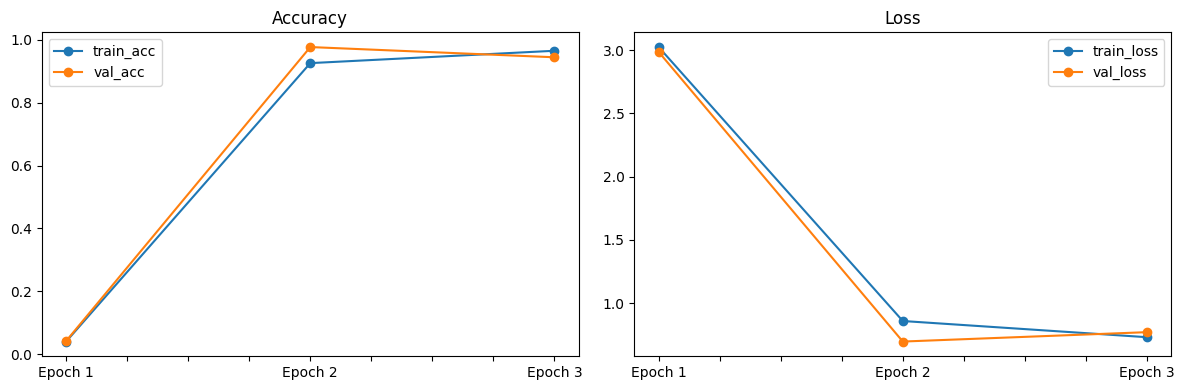

Training curves saved.


In [11]:
# ── CELL 9: Training curves ─────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import os, torch

# Detect which arch was used (depends on whether GPU was available)
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'

df = pd.DataFrame(history).round(4)
df.index = [f'Epoch {i+1}' for i in range(len(df))]
print(df.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df[['train_acc', 'val_acc']].plot(ax=ax1, marker='o', title='Accuracy')
df[['train_loss', 'val_loss']].plot(ax=ax2, marker='o', title='Loss')
plt.tight_layout()

out_dir = '/content/drive/MyDrive/idea4drive/eval_outputs'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved.')


In [12]:
# ── CELL 10: Evaluate on PV val (source) AND PlantDoc (target) ──────
import sys, os, torch
sys.path.append('/content/drive/MyDrive/idea4drive')

import importlib, evaluate as _ev
importlib.reload(_ev)
from evaluate import evaluate

# Auto-detect which checkpoint to use based on device/arch
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'
CKPT = f'/content/drive/MyDrive/idea4drive/checkpoints/best_{arch}.pth'
PV_VAL = '/content/final_dataset/val'
PD_VAL = '/content/plantdoc_aligned/val'
OUTPUT_DIR = '/content/drive/MyDrive/idea4drive/eval_outputs'

# Guard: rebuild datasets if session restarted
for path, name in [(PV_VAL, 'PV val'), (PD_VAL, 'PlantDoc aligned val')]:
    if not os.path.isdir(path):
        raise RuntimeError(f'{name} not found at {path} — re-run Cell 6 first.')
if not os.path.isfile(CKPT):
    raise RuntimeError(f'Checkpoint not found: {CKPT} — run Cell 8 first.')

pv_imgs = sum(len(os.listdir(os.path.join(PV_VAL, c))) for c in os.listdir(PV_VAL) if os.path.isdir(os.path.join(PV_VAL, c)))
pd_imgs = sum(len(os.listdir(os.path.join(PD_VAL, c))) for c in os.listdir(PD_VAL) if os.path.isdir(os.path.join(PD_VAL, c)))
print(f'PV val:     OK ({pv_imgs} images)')
print(f'PD aligned: OK ({pd_imgs} images)')
print(f'Checkpoint: OK ({os.path.getsize(CKPT)/1e6:.1f} MB) — arch: {arch}')
print()

eval_results = evaluate(
    checkpoint_path = CKPT,
    pv_val_dir      = PV_VAL,
    pd_eval_dir     = PD_VAL,
    arch            = arch,
    batch_size      = 32,
    output_dir      = OUTPUT_DIR,
)
print('\nEvaluation complete. Results saved to Drive.')


PV val:     OK (4743 images)
PD aligned: OK (1679 images)
Checkpoint: OK (18.0 MB) — arch: mobilenet_v3_small


Evaluation complete. Results saved to Drive.


In [13]:
import sys
sys.path.append('/content/drive/MyDrive/idea4drive')

In [3]:
# ── CELL 11: Domain gap analysis ────────────────────────────────────
import os, sys, torch, importlib
sys.path.append('/content/drive/MyDrive/idea4drive')

import domain_gap as _dg, evaluate as _ev
importlib.reload(_dg)
importlib.reload(_ev)
from domain_gap import compute_domain_gap
from evaluate import evaluate, load_model_from_checkpoint

# Auto-detect arch
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'
CKPT       = f'/content/drive/MyDrive/idea4drive/checkpoints/best_{arch}.pth'
PV_VAL     = '/content/final_dataset/val'
PD_VAL     = '/content/plantdoc_aligned/val'
OUTPUT_DIR = '/content/drive/MyDrive/idea4drive/eval_outputs'

# Guards
for path, name in [(PV_VAL, 'PV val'), (PD_VAL, 'PD val')]:
    if not os.path.isdir(path):
        raise RuntimeError(f'{name} not found — re-run Cell 6 first.')
if not os.path.isfile(CKPT):
    raise RuntimeError(f'Checkpoint not found: {CKPT} — run Cell 8 first.')

# Auto-run evaluation if eval_results not in scope
if 'eval_results' not in dir() and 'eval_results' not in globals():
    print('eval_results not found — running evaluation first...')
    eval_results = evaluate(
        checkpoint_path = CKPT,
        pv_val_dir      = PV_VAL,
        pd_eval_dir     = PD_VAL,
        arch            = arch,
        batch_size      = 32,
        output_dir      = OUTPUT_DIR,
    )
    print('Evaluation complete.')
else:
    print('eval_results found — skipping re-evaluation.')

model = load_model_from_checkpoint(CKPT, arch=arch)

gap_results = compute_domain_gap(
    model           = model,
    pv_val_dir      = PV_VAL,
    pd_eval_dir     = PD_VAL,
    eval_results    = eval_results,
    output_dir      = OUTPUT_DIR,
    mmd_sample_size = 2000,
)
print('\nDomain gap analysis complete.')


eval_results not found — running evaluation first...
Evaluation complete.

Domain gap analysis complete.


In [4]:
# ── CELL 12: Structured benchmark results table ──────────────────────────
import json, os

out = '/content/drive/MyDrive/idea4drive/eval_outputs'

pv = eval_results.get('pv_val', {})
pd_r = eval_results.get('pd_eval', {})
gap = gap_results

print('=' * 65)
print('BENCHMARK RESULTS SUMMARY — Lab-to-Field Domain Generalisation')
print('=' * 65)
print(f"{'Metric':<35} {'PV-val (source)':>18} {'PD-eval (target)':>18}")
print('-' * 65)
print(f"{'Accuracy':<35} {pv.get('accuracy',0)*100:>17.2f}% {pd_r.get('accuracy',0)*100:>17.2f}%")
print(f"{'Macro-F1':<35} {pv.get('macro_f1',0):>18.4f} {pd_r.get('macro_f1',0):>18.4f}")
print(f"{'Weighted-F1':<35} {pv.get('weighted_f1',0):>18.4f} {pd_r.get('weighted_f1',0):>18.4f}")
print(f"{'# Samples':<35} {pv.get('n_samples',0):>18d} {pd_r.get('n_samples',0):>18d}")
print('=' * 65)

drop = gap.get('performance_drop', {})
if drop:
    print(f"\nDomain Gap (PV → PD):")
    print(f"  Δ Accuracy  : {drop.get('delta_accuracy',0):+.4f}  ({drop.get('relative_accuracy_drop_pct',0):+.1f}% relative)")
    print(f"  Δ Macro-F1  : {drop.get('delta_macro_f1',0):+.4f}  ({drop.get('relative_f1_drop_pct',0):+.1f}% relative)")

mmd = gap.get('mmd', {})
cen = gap.get('centroid_distance', {})
if mmd:
    print(f"\nFeature-space gap metrics:")
    print(f"  MMD²              : {mmd.get('mmd_squared', 0):.6f}  (σ={mmd.get('sigma',0):.4f})")
    print(f"  Centroid L2 dist  : {cen.get('centroid_distance',0):.6f}")
    print(f"  Centroid cos-sim  : {cen.get('cosine_similarity',0):.6f}")

print('=' * 65)

# Save full summary JSON
summary = {
    'pv_val':  {k: v for k, v in pv.items()   if k not in ('report_str', 'confusion_matrix', '_pv_inference', '_pd_inference')},
    'pd_eval': {k: v for k, v in pd_r.items() if k not in ('report_str', 'confusion_matrix', '_pv_inference', '_pd_inference')},
    'domain_gap': gap,
}
summary_path = os.path.join(out, 'benchmark_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nFull summary saved to: {summary_path}')

BENCHMARK RESULTS SUMMARY — Lab-to-Field Domain Generalisation
Metric                                 PV-val (source)   PD-eval (target)
-----------------------------------------------------------------
Accuracy                                        97.70%             26.56%
Macro-F1                                        0.9680             0.2011
Weighted-F1                                     0.9769             0.2350
# Samples                                         4743               1679

Domain Gap (PV → PD):
  Δ Accuracy  : +0.7114  (+72.8% relative)
  Δ Macro-F1  : +0.7669  (+79.2% relative)

Feature-space gap metrics:
  MMD²              : 0.125250  (σ=0.8382)
  Centroid L2 dist  : 0.447551
  Centroid cos-sim  : 0.745183

Full summary saved to: /content/drive/MyDrive/idea4drive/eval_outputs/benchmark_summary.json
